# Multilingual Health QA in Low-Resource African Languages
### Unified end-to-end notebook (EDA → retrieval → fine-tuning → submission)

**Governing insight:** the metric is `0.37·ROUGE-1 + 0.37·ROUGE-L + 0.26·LLM-judge` → **74% is
lexical overlap**, so the system is **retrieval-first**, with fine-tuning layered on the configs
where retrieval is structurally capped (≈99%-unique answers). Best public score: **0.598**.

Cells adapt to the environment: on **Colab** they clone the repo, upload data and train on GPU;
run **locally** (repo + `Data/` present) they reuse cached artifacts. Use a GPU runtime on Colab.

## 1. Setup

In [1]:
import os, sys
IN_COLAB = 'google.colab' in sys.modules or os.path.isdir('/content')
if not os.path.isdir('src') and IN_COLAB:
    !git clone https://github.com/<your-username>/hash-multilingual-health-qa.git
    %cd hash-multilingual-health-qa
if os.path.isdir('src'):
    sys.path.append('src')
try:
    import pandas, sklearn, rouge_score  # already present locally
except ImportError:
    !pip install -q -r requirements.txt
print('setup complete | cwd:', os.getcwd())

setup complete | cwd: /Users/kelvinrwihimba/Documents/Final Summative/QA_Summative_ML/QA_Multilingual_Summative


## 2. Data
`Train.csv`, `Val.csv`, `Test.csv` (challenge files, not redistributed in the repo).

In [2]:
import os
os.makedirs('Data', exist_ok=True)
have = all(os.path.exists(f'Data/{f}') for f in ['Train.csv', 'Val.csv', 'Test.csv'])
if not have:
    try:
        from google.colab import files
        up = files.upload()
        for n in up:
            if n.endswith('.csv') and n != 'SampleSubmission.csv':
                os.replace(n, f'Data/{n}')
    except Exception:
        print('Place Train.csv, Val.csv, Test.csv in Data/')
print('Data/:', sorted(os.listdir('Data')))

Data/: ['Test.csv', 'Train.csv', 'Val.csv']


## 3. Exploratory Data Analysis
The decisive variable is **answer uniqueness** per subset.

In [3]:
import pandas as pd
tr = pd.read_csv('Data/Train.csv'); va = pd.read_csv('Data/Val.csv'); te = pd.read_csv('Data/Test.csv')
print('shapes:', tr.shape, va.shape, te.shape)
dup = (tr.groupby('subset').output.nunique() / tr.groupby('subset').size()).sort_values()
print('\nanswer uniqueness (unique/rows) per subset:'); print(dup.round(3))
print('\ntest mix %:'); print((te.subset.value_counts(normalize=True) * 100).round(1))

shapes: (29815, 4) (6686, 4) (2618, 3)



answer uniqueness (unique/rows) per subset:
subset
Eng_Uga    0.238
Lug_Uga    0.329
Eng_Ken    0.474
Swa_Ken    0.476
Eng_Eth    0.740
Eng_Gha    0.985
Aka_Gha    0.996
Amh_Eth    0.996
dtype: float64

test mix %:
subset
Eng_Uga    28.4
Aka_Gha    18.8
Eng_Gha    18.8
Lug_Uga    14.3
Swa_Ken     8.7
Eng_Ken     6.4
Amh_Eth     2.3
Eng_Eth     2.3
Name: proportion, dtype: float64


wrote fig1_subset_distribution.png


wrote fig2_answer_dup_rate.png


wrote fig3_answer_length.png


wrote fig4_experiment_progression.png


wrote fig5_per_subset_v5.png


wrote fig6_retrieval_vs_oracle.png


wrote fig7_calibration.png


wrote fig8_learning_curves.png


wrote fig9_generation_vs_retrieval.png

All figures in /Users/kelvinrwihimba/Documents/Final Summative/QA_Summative_ML/QA_Multilingual_Summative/reports/figures


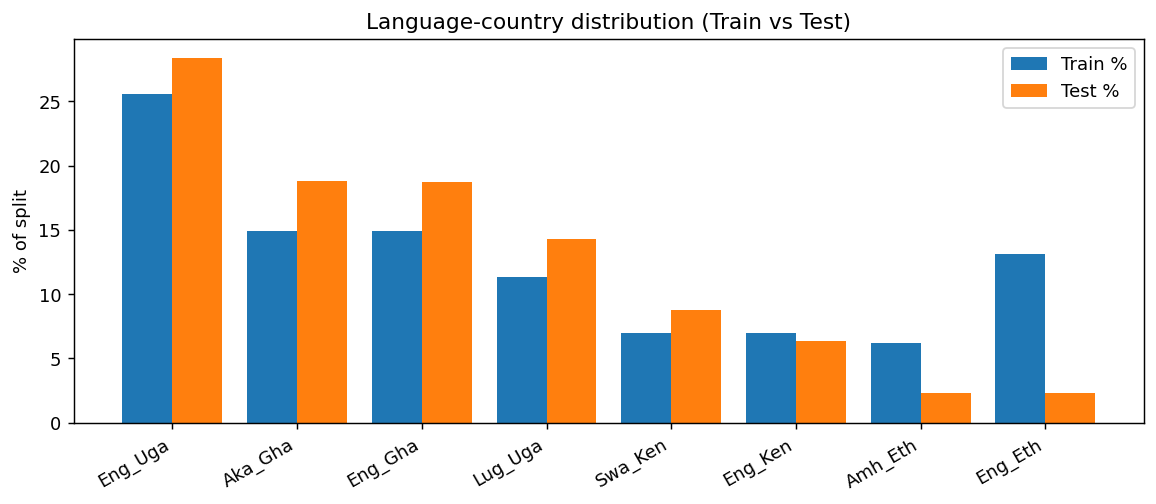

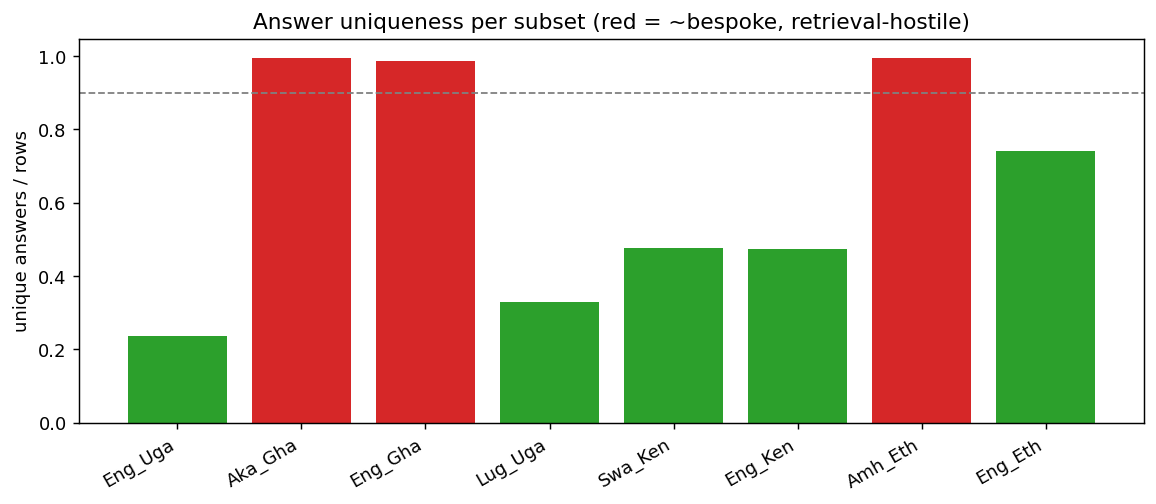

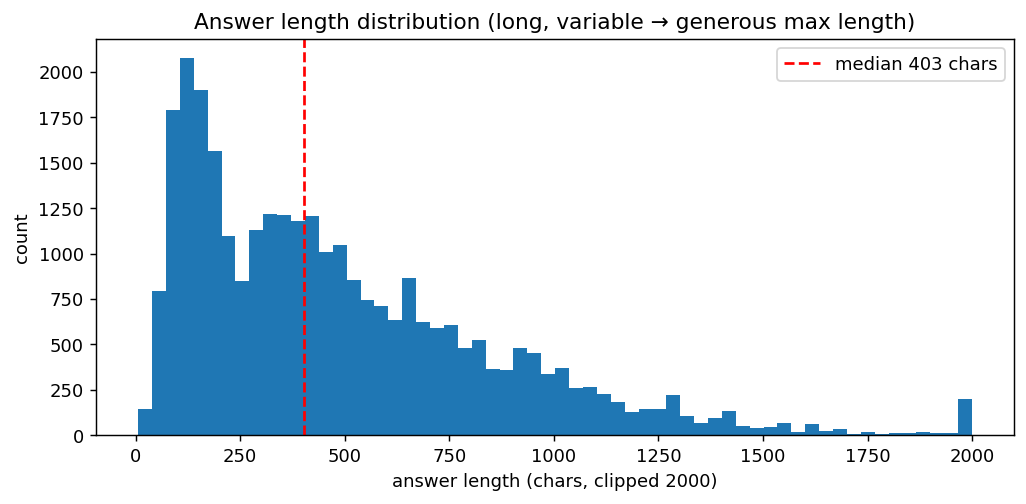

In [4]:
!python src/make_figures.py
from IPython.display import Image, display
for f in ['fig1_subset_distribution.png', 'fig2_answer_dup_rate.png', 'fig3_answer_length.png']:
    display(Image(f'reports/figures/{f}'))

## 4. Retrieval pipeline
Baseline → per-subset routing + global bank → MPNet rerank → Ghana hybrid (each Val-gated).

In [5]:
# 4a. Baseline floor (CPU): per-language char_wb TF-IDF nearest-answer
!python src/baseline_retrieval.py


=== baseline_char_wb_2_5 : LOCAL VAL ===
OVERALL  R1=0.4622  RL=0.3890  portion(/0.74)=0.3150  mean_rouge=0.4256


  Aka_Gha  n= 1114  R1=0.3866  RL=0.2181  portion=0.2237
  Amh_Eth  n=  462  R1=0.0268  RL=0.0268  portion=0.0199


  Eng_Eth  n=  564  R1=0.5517  RL=0.5239  portion=0.3980


  Eng_Gha  n= 1104  R1=0.3090  RL=0.1947  portion=0.1864


  Eng_Ken  n=  390  R1=0.6309  RL=0.5857  portion=0.4501


  Eng_Uga  n= 1688  R1=0.5692  RL=0.5171  portion=0.4019


  Lug_Uga  n=  846  R1=0.5495  RL=0.5106  portion=0.3922


  Swa_Ken  n=  518  R1=0.6244  RL=0.5825  portion=0.4465


Wrote /Users/kelvinrwihimba/Documents/Final Summative/QA_Summative_ML/QA_Multilingual_Summative/submissions/submission_baseline.csv  (2618 rows)


In [6]:
# 4b. Best retrieval submission: rerank + Ghana hybrid (+ Val-bank for Test)
#     prints the honest Train-only Val scoreboard, writes submissions/submission_v4.csv
!python src/make_submission_v4.py

[cache] loaded val rerank preds



=== v4: rerank + Ghana hybrid (Train-only eval) : LOCAL VAL ===
OVERALL  R1=0.5366  RL=0.4636  portion(/0.74)=0.3701  mean_rouge=0.5001


  Aka_Gha  n= 1114  R1=0.4472  RL=0.2649  portion=0.2635
  Amh_Eth  n=  462  R1=0.0309  RL=0.0309  portion=0.0229


  Eng_Eth  n=  564  R1=0.5800  RL=0.5523  portion=0.4189


  Eng_Gha  n= 1104  R1=0.3959  RL=0.2686  portion=0.2459


...

  Lug_Uga  n=  846  R1=0.5661  RL=0.5294  portion=0.4053


  Swa_Ken  n=  518  R1=0.6596  RL=0.6166  portion=0.4722


/Users/kelvinrwihimba/Documents/Final Summative/QA_Summative_ML/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


[rerank] encoder=sentence-transformers/paraphrase-multilingual-mpnet-base-v2 device=mps


Wrote /Users/kelvinrwihimba/Documents/Final Summative/QA_Summative_ML/QA_Multilingual_Summative/submissions/submission_v4.csv  (2618 rows)


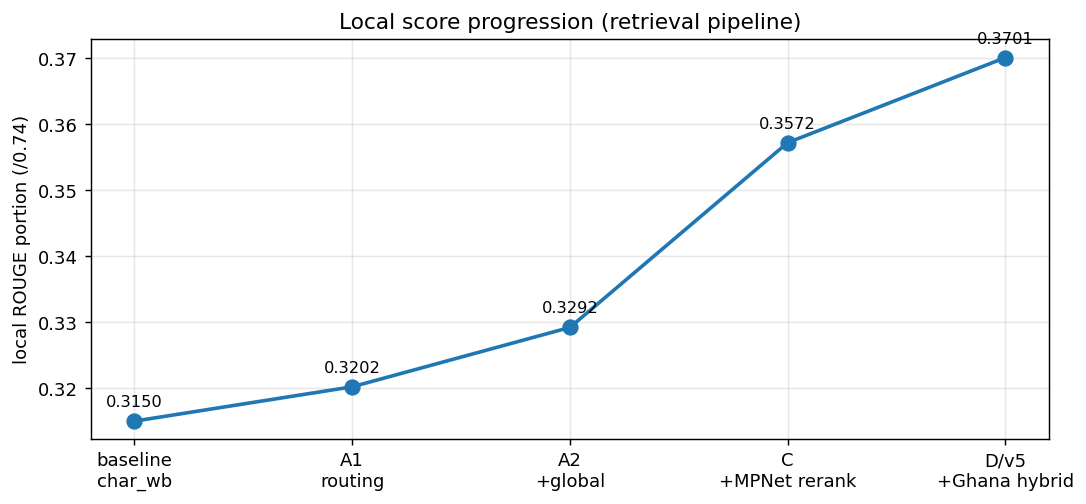

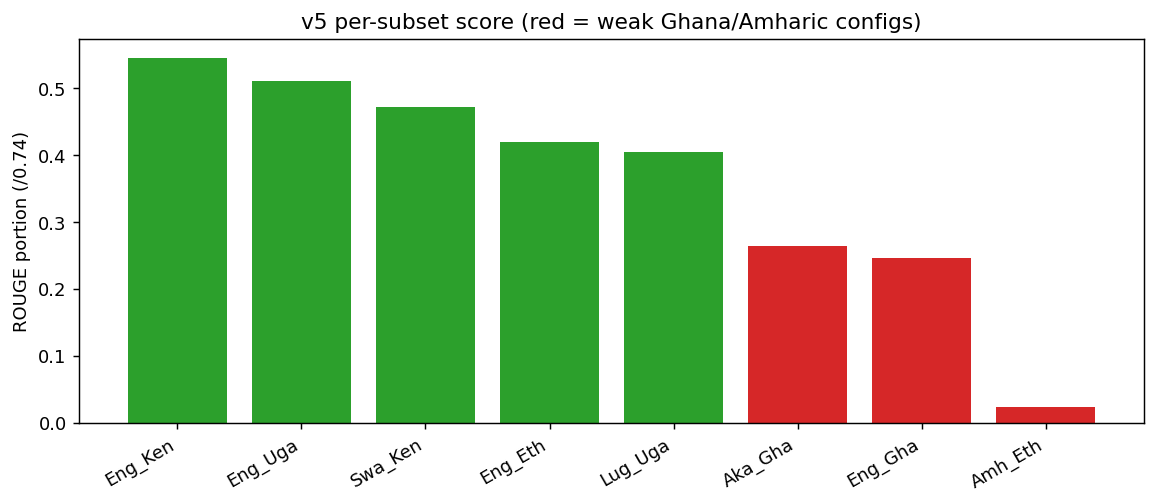

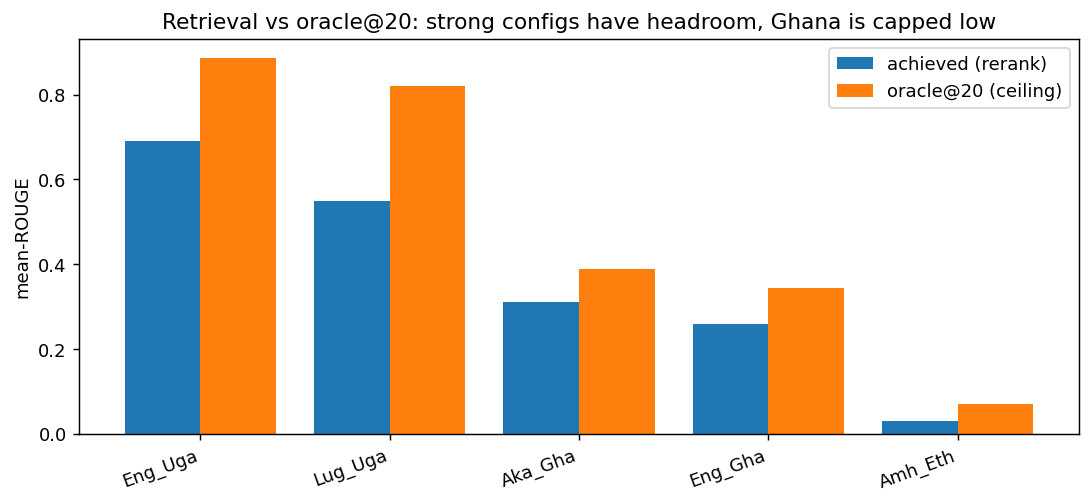

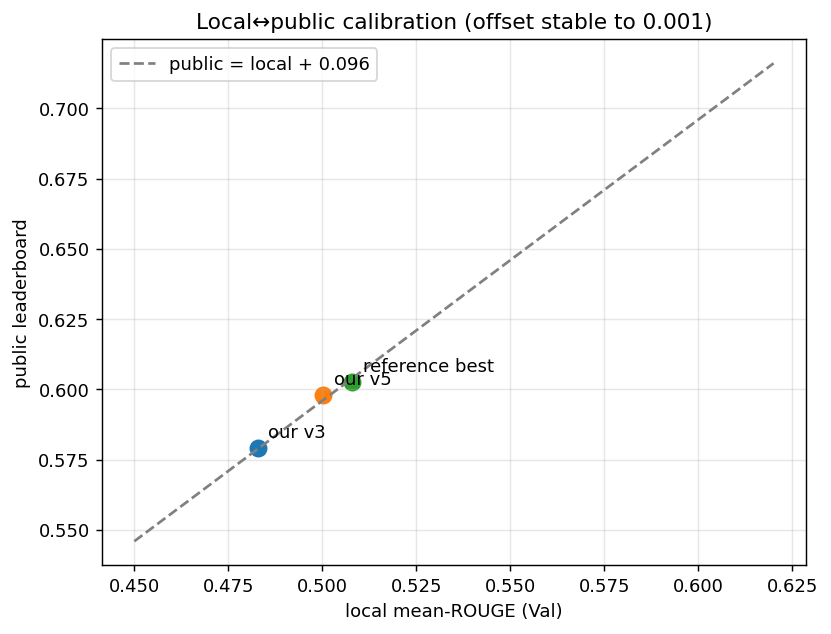

In [7]:
for f in ['fig4_experiment_progression.png', 'fig5_per_subset_v5.png',
          'fig6_retrieval_vs_oracle.png', 'fig7_calibration.png']:
    display(Image(f'reports/figures/{f}'))

## 5. Fine-tuning (GPU) — mT5 on the Ghana configs
Retrieval is capped on Ghana (oracle@20 ≈ 0.39). We fine-tune mT5-small (full + LoRA/PEFT).
If a run already exists in `generator_outputs/` it is reused; otherwise it trains (GPU, ~15–25 min).

In [8]:
import os
if os.path.exists('generator_outputs/mt5small_full/val_gen.csv'):
    import json
    print('Reusing existing mt5small_full run:')
    print(json.dumps(json.load(open('generator_outputs/mt5small_full/metrics.json'))['per_subset'], indent=2))
else:
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
    !PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True python src/train_generator.py \
        --data-dir Data --output-dir generator_outputs --run-name mt5small_full \
        --model-name google/mt5-small --subsets Aka_Gha,Eng_Gha \
        --epochs 2 --train-bs 16 --grad-accum 1 --lr 1e-3 \
        --max-input 96 --max-target 160 --gen-len 160 --beams 2 --seed 42

Reusing existing mt5small_full run:
{
  "Aka_Gha": {
    "gen_mean_rouge": 0.3238,
    "retrieval_baseline": 0.356,
    "n": 1114
  },
  "Eng_Gha": {
    "gen_mean_rouge": 0.3076,
    "retrieval_baseline": 0.332,
    "n": 1104
  }
}


In [9]:
import os
if os.path.exists('generator_outputs/mt5small_lora/val_gen.csv'):
    print('Reusing existing mt5small_lora (LoRA/PEFT) run.')
else:
    !PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True python src/train_generator.py \
        --data-dir Data --output-dir generator_outputs --run-name mt5small_lora \
        --model-name google/mt5-small --subsets Aka_Gha,Eng_Gha --use-lora \
        --epochs 2 --train-bs 16 --grad-accum 1 --lr 5e-4 \
        --max-input 96 --max-target 160 --gen-len 160 --beams 2 --seed 42

Reusing existing mt5small_lora (LoRA/PEFT) run.


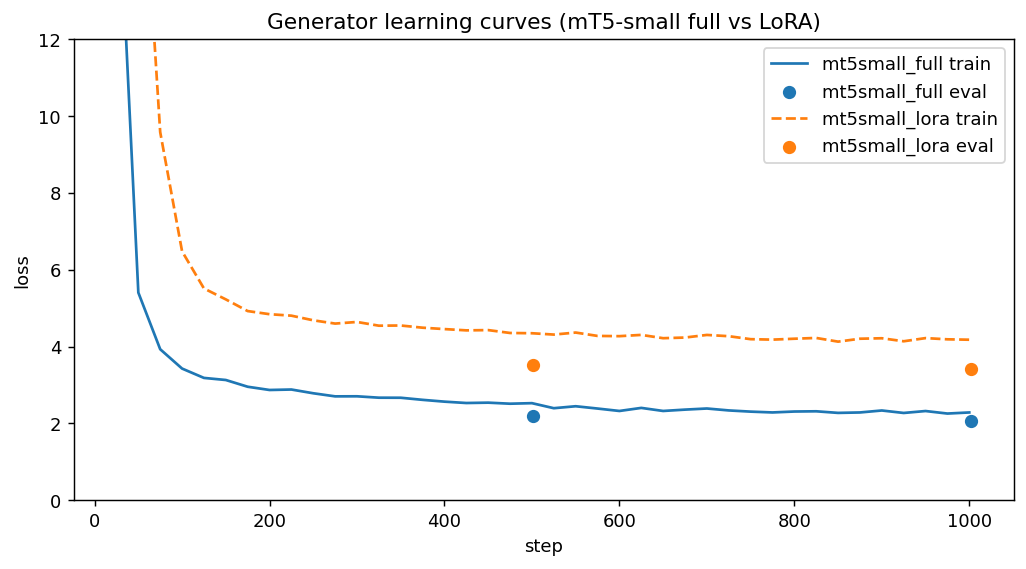

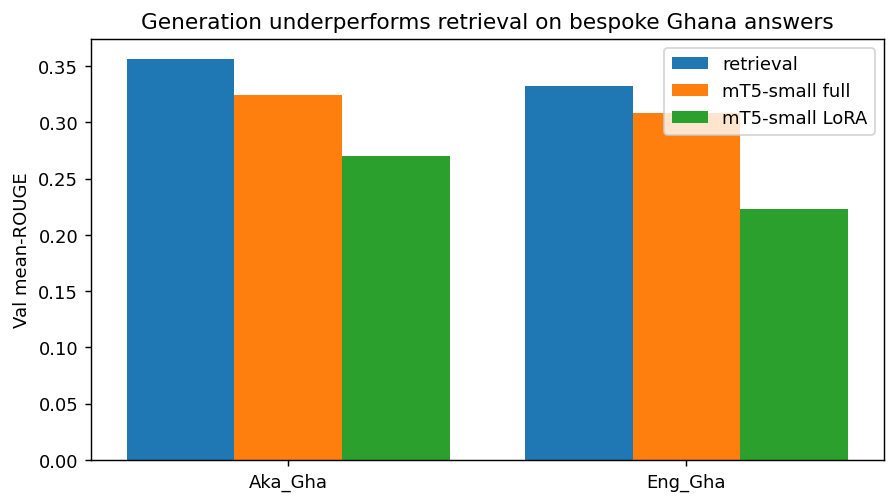

In [10]:
for f in ['fig8_learning_curves.png', 'fig9_generation_vs_retrieval.png']:
    display(Image(f'reports/figures/{f}'))

## 6. Gate + final submission
Replace a Ghana answer with generation ONLY if it beats retrieval on that subset's Val.

In [11]:
!python src/make_submission_v5.py --gen-dir generator_outputs/mt5small_full
import pandas as pd
s = pd.read_csv('submissions/submission_v5.csv')
print('final submission rows:', len(s), '| columns:', list(s.columns))

Per-subset Val gate (generation vs retrieval mean-ROUGE):


  Aka_Gha: retrieval=0.3560  generation=0.3238  -> use retrieval


  Eng_Gha: retrieval=0.3323  generation=0.3076  -> use retrieval



=== v5: retrieval+hybrid with Val-gated generation : LOCAL VAL ===
OVERALL  R1=0.5366  RL=0.4636  portion(/0.74)=0.3701  mean_rouge=0.5001


  Aka_Gha  n= 1114  R1=0.4472  RL=0.2649  portion=0.2635
  Amh_Eth  n=  462  R1=0.0309  RL=0.0309  portion=0.0229


...

  Eng_Uga  n= 1688  R1=0.7090  RL=0.6713  portion=0.5107


  Lug_Uga  n=  846  R1=0.5661  RL=0.5294  portion=0.4053


  Swa_Ken  n=  518  R1=0.6596  RL=0.6166  portion=0.4722


Wrote /Users/kelvinrwihimba/Documents/Final Summative/QA_Summative_ML/QA_Multilingual_Summative/submissions/submission_v5.csv  (2618 rows)


final submission rows: 2618 | columns: ['ID', 'TargetRLF1', 'TargetR1F1', 'TargetLLM']


## 7. Results
| Stage | Local portion (/0.74) | Public |
|---|---:|---:|
| Baseline | 0.3150 | — |
| + routing + global bank | 0.3292 | — |
| + MPNet rerank | 0.3572 | 0.579 |
| **+ Ghana hybrid (best)** | **0.3701** | **0.598** |

Validated mapping **`public ≈ local + 0.096`**. The ceiling is set by answer uniqueness, not
model quality — the central, evidence-backed finding. Full analysis, the 14 documented
experiments, ethics and future work: `reports/REPORT.md` / `REPORT.html`.